# Notebook 2 - Exploratory Data Analysis (EDA)
**Owner:** Member 2

**Input:** `data/processed/cleaned_insurance.csv`

**Goal:** Understand relationships between features and `charges`, and extract insights
that guide model selection.

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")

FIGURES_DIR = "../reports/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

df = pd.read_csv("../data/processed/cleaned_insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Target Distribution

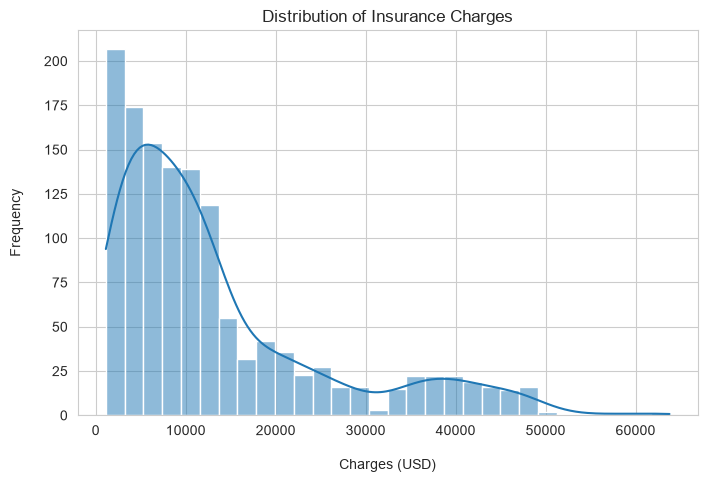

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["charges"], bins=30, kde=True, ax=ax)
ax.set_title("Distribution of Insurance Charges")
ax.set_xlabel("Charges (USD)",labelpad=15)
ax.set_ylabel("Frequency",labelpad=15)
fig.savefig(f"{FIGURES_DIR}/target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


**Note:** `charges` is right-skewed - most people have lower costs, with a long tail of high-cost cases.

## 3. BMI Distribution

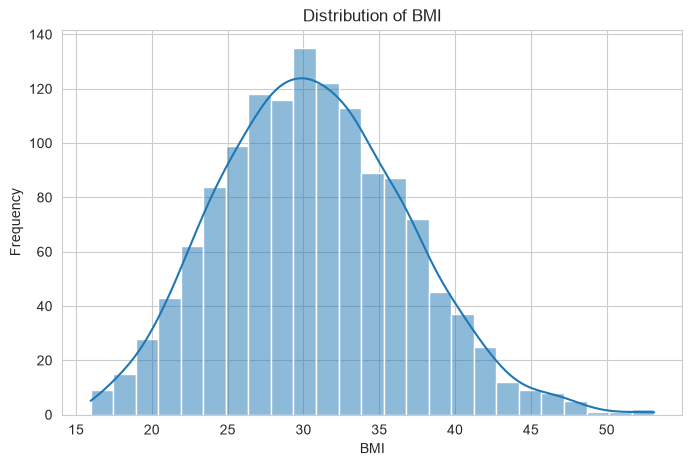

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["bmi"], bins=25, kde=True, ax=ax)
ax.set_title("Distribution of BMI")
ax.set_xlabel("BMI",labelpad=15)
ax.set_ylabel("Frequency",labelpad=15)
fig.savefig(f"{FIGURES_DIR}/bmi_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


**Note:** BMI is close to a normal distribution, with a slight right tail (some high-BMI cases).

## 4. Smoker Count

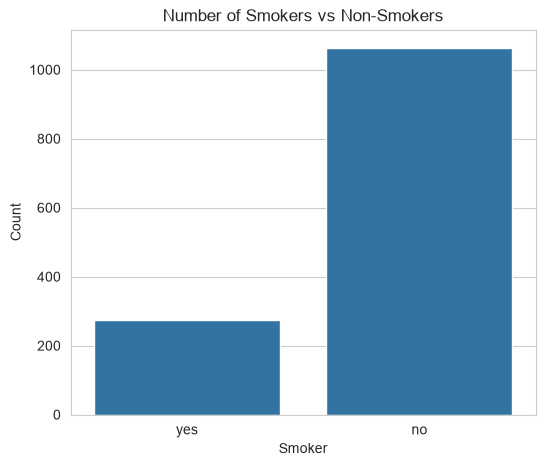

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.countplot(x="smoker", data=df, ax=ax)
ax.set_title("Number of Smokers vs Non-Smokers")
ax.set_xlabel("Smoker")
ax.set_ylabel("Count")
fig.savefig(f"{FIGURES_DIR}/smoker_count.png", dpi=150, bbox_inches="tight")
plt.show()


**Note:** Non-smokers make up the majority of the dataset (roughly 4x more than smokers).

## 5. Correlation Heatmap
We use One-Hot Encoding for `region` (not LabelEncoder, since region has no natural order).

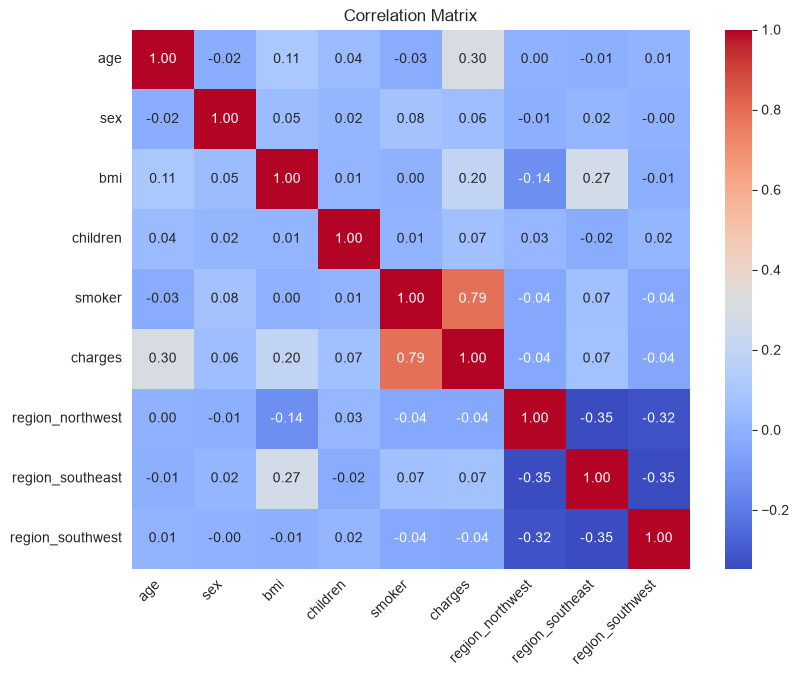

In [11]:
temp = df.copy()
temp["sex"] = temp["sex"].map({"male": 1, "female": 0})
temp["smoker"] = temp["smoker"].map({"yes": 1, "no": 0})
temp = pd.get_dummies(temp, columns=["region"], drop_first=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(temp.corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Matrix")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha="right")
fig.savefig(f"{FIGURES_DIR}/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


**Note:** `smoker` has by far the strongest correlation with `charges`, followed by `age` and `bmi`.

## 6. Smoker vs Charges

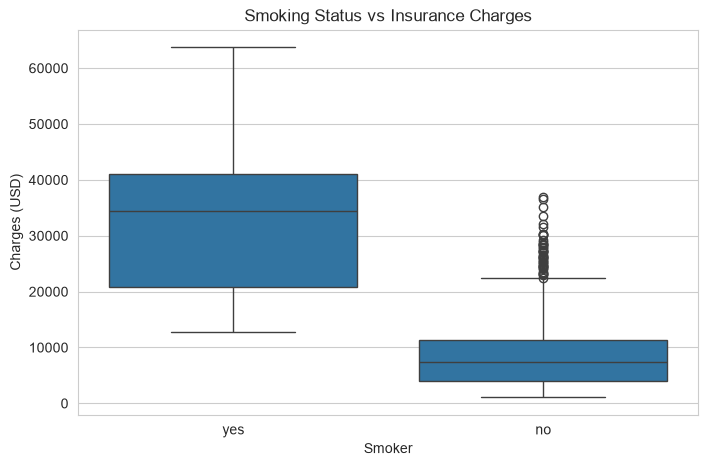

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x="smoker", y="charges", data=df, ax=ax)
ax.set_title("Smoking Status vs Insurance Charges")
ax.set_xlabel("Smoker")
ax.set_ylabel("Charges (USD)")
fig.savefig(f"{FIGURES_DIR}/smoker_vs_charges.png", dpi=150, bbox_inches="tight")
plt.show()

print(df.groupby("smoker")["charges"].mean())


**Note:** Smokers pay roughly 3-4x more on average. This is the strongest signal in the dataset.

## 7. Age vs Charges

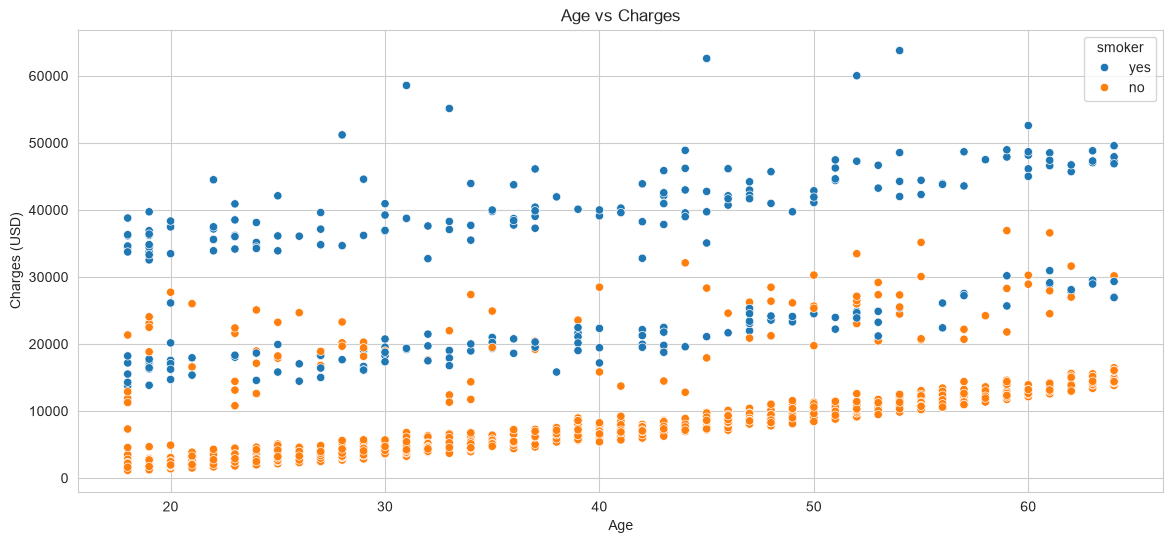

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.scatterplot(x="age", y="charges", hue="smoker", data=df, ax=ax)
ax.set_title("Age vs Charges")
ax.set_xlabel("Age")
ax.set_ylabel("Charges (USD)")
fig.savefig(f"{FIGURES_DIR}/age_vs_charges.png", dpi=150, bbox_inches="tight")
plt.show()


**Note:** Charges increase with age within each group, but smokers start from a much higher baseline.

## 8. BMI vs Charges

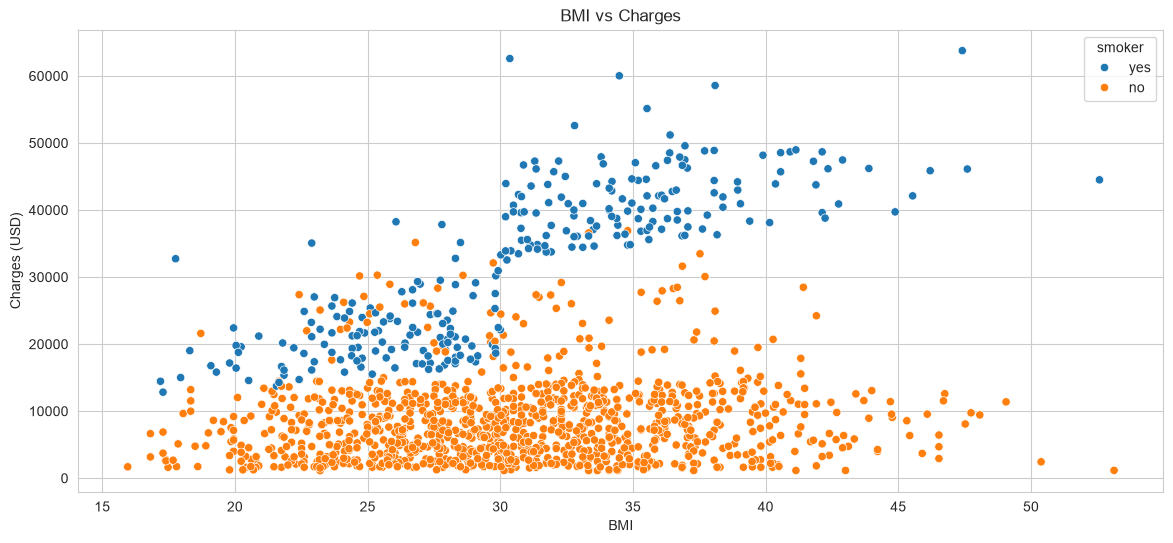

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.scatterplot(x="bmi", y="charges", hue="smoker", data=df, ax=ax)
ax.set_title("BMI vs Charges")
ax.set_xlabel("BMI")
ax.set_ylabel("Charges (USD)")
fig.savefig(f"{FIGURES_DIR}/bmi_vs_charges.png", dpi=150, bbox_inches="tight")
plt.show()


**Note:** BMI has little effect on charges for non-smokers, but a strong effect for smokers (especially above BMI ~30). This is the interaction we captured as `bmi_smoker` in preprocessing.

## 9. Summary of Insights

1. `smoker` is the single strongest driver of `charges`.
2. `age` and `bmi` both increase charges, and `bmi`'s effect is much stronger for smokers (interaction).
3. `region` has almost no effect on `charges` (dropped from the chart set for this reason).
4. `charges` is right-skewed, which motivates the log-transform used for Linear Regression.
5. Tree-based models (Decision Tree, Random Forest) are expected to outperform Linear Regression,
   since they can naturally capture the smoker/bmi interaction.


## Deliverables - Member 2
- [x] Charts saved in `reports/figures/`
- [x] Insights documented (Section 9)
